In [1]:
import sys, os, pygmt, importlib
mod_path = '/home/581/da1339/AFIM/src/AFIM/src'
sys.path.insert(0, mod_path)
from sea_ice_toolbox         import SeaIceToolbox, SeaIceToolboxManager
import numpy                 as np
import pandas                as pd
import xarray                as xr
import xesmf                 as xe
import matplotlib.pyplot     as plt
from pathlib                 import Path

In [2]:
D_cfg      = Path.home() / "AFIM" / "src" / "AFIM" / "src" / "JSONs"
ice_type   = 'FI' 
dt0, dtN   = '1993-01-01', '1993-12-31'
hemisphere = 'south'
sim_names  = ["waves"]
BorC2T     = ['Tc']
P_log      = Path.home() / "logs" / f"modifying_GIBs.log"
mgr        = SeaIceToolboxManager(P_log = P_log)
tb         = mgr.get_toolbox(P_json         = D_cfg / "sea_ice_free-slip.json",
                             sim_name       = sim_names[0], 
                             dt0_str        = dt0,
                             dtN_str        = dtN,
                             list_of_BorC2T = BorC2T[0],
                             ice_type       = ice_type,
                             hemisphere     = hemisphere)
tb.kmt_mod            = {}
tb.kmt_mod["kmt_mod"] = tb.modify_landmask_with_grounded_icebergs(GI_P_raw="/home/581/da1339/AFIM_gv90/grounded_icebergs/Kaihong_Jiao/Grounded_Icebergs_Dataset.gpkg",
                                                                  strategy="ranked_area",
                                                                  keep_fraction=0.103,
                                                                  dedup_uid=True)
n_gi, a_gi = tb.compute_grounded_iceberg_cell_count(return_area=True)
print(n_gi, a_gi/1e9)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45403 instead
  warnings.warn(
2026-03-27 18:42:39,140 - INFO - log file connected: /home/581/da1339/logs/modifying_GIBs.log
2026-03-27 18:42:39,146 - INFO - Dask Client Connected
  Dashboard      : /proxy/45403/status
  Threads        : 4
  Threads/Worker : [1, 1, 1, 1]
  Total Memory   : 64.00 GB

2026-03-27 18:42:39,147 - INFO - hemisphere initialised: SH
2026-03-27 18:42:39,149 - INFO - reading /g/data/gv90/da1339/afim_output/waves/ice_diag.d to construct /g/data/gv90/da1339/afim_output/waves/ice_in_AFIM_subset_waves.json
2026-03-27 18:42:39,153 - INFO - --- SeaIceToolbox Summary ---
2026-03-27 18:42:39,154 - INFO - Simulation Name     : waves
2026-03-27 18:42:39,155 - INFO - Analysis Start Date : 1993-01-01
2026-03-27 18:42:39,155 - INFO - Analysis End Date

583 66.09336526361768


In [5]:
tb.write_modified_landmask_and_counts_to_disk(GI_thin_fact = 1-0.103, GI_version_str = "2p0", overwrite=False)

modified KMT     : /g/data/gv90/da1339/grounded_icebergs/MyThin_db/GI_thinned-0p90_v2p0_iter0.nc
thinned GI count : /g/data/gv90/da1339/grounded_icebergs/MyThin_db/kmt_mod_thinned-0p90_v2p0_iter0.nc
Modified KMT and GI-count-file do not exist. Writing out the above files


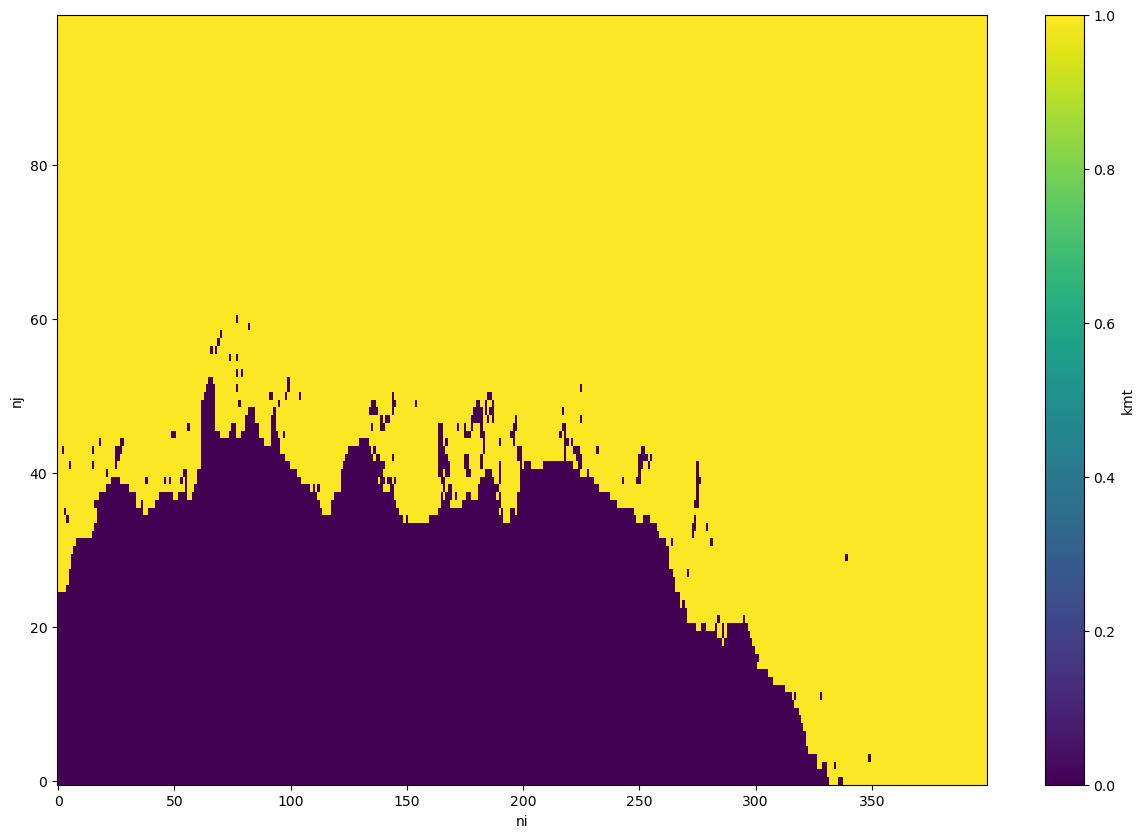

In [17]:
tb.kmt_mod['kmt_mod'].isel(nj=slice(100,200),ni=slice(0,400)).plot(figsize=(15,10))

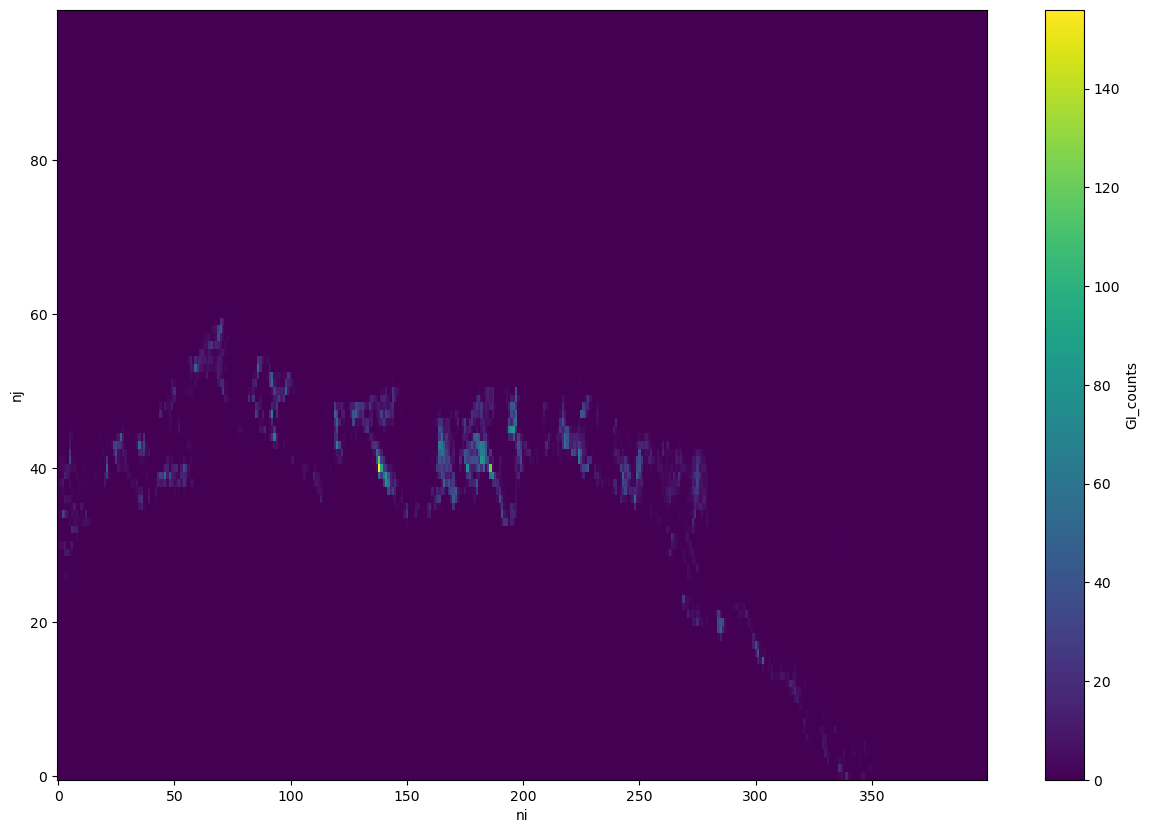

In [18]:
tb.GI_cnts.isel(nj=slice(100,200),ni=slice(0,400)).plot(figsize=(15,10))

In [7]:
D_cfg      = Path.home() / "AFIM" / "src" / "AFIM" / "src" / "JSONs"
ice_type   = 'FI' 
dt0, dtN   = '1993-01-01', '1993-12-31'
hemisphere = 'south'
sim_names  = ["elps-min"]
BorC2T     = ['Tb']
P_log = Path.home() / "logs" / f"modifying_GIBs.log"
mgr   = SeaIceToolboxManager(P_log = P_log)
tb    = mgr.get_toolbox(P_json         = D_cfg / "sea_ice_config.json",
                        sim_name       = sim_names[0],
                        dt0_str        = dt0,
                        dtN_str        = dtN,
                        list_of_BorC2T = BorC2T[0],
                        ice_type       = ice_type,
                        hemisphere     = hemisphere)
n_gi, a_gi = tb.compute_grounded_iceberg_cell_count(return_area=True)
print(n_gi, a_gi/1e9)

2026-03-27 18:26:32,700 - INFO - log file connected: /home/581/da1339/logs/modifying_GIBs.log
2026-03-27 18:26:32,714 - INFO - Dask Client Connected
  Dashboard      : /proxy/45149/status
  Threads        : 4
  Threads/Worker : [1, 1, 1, 1]
  Total Memory   : 64.00 GB

2026-03-27 18:26:32,715 - INFO - hemisphere initialised: SH
2026-03-27 18:26:32,716 - INFO - reading /g/data/gv90/da1339/afim_output/elps-min/ice_diag.d to construct /g/data/gv90/da1339/afim_output/elps-min/ice_in_AFIM_subset_elps-min.json
2026-03-27 18:26:32,718 - INFO - --- SeaIceToolbox Summary ---
2026-03-27 18:26:32,719 - INFO - Simulation Name     : elps-min
2026-03-27 18:26:32,720 - INFO - Analysis Start Date : 1993-01-01
2026-03-27 18:26:32,721 - INFO - Analysis End Date   : 1993-12-31
2026-03-27 18:26:32,722 - INFO - grid file           : /g/data/gv90/da1339/grids/ACCESS-OM2-025_grid.nc
2026-03-27 18:26:32,723 - INFO - landmask file       : /g/data/gv90/da1339/grids/ACCESS-OM2-025_kmt.nc
2026-03-27 18:26:32,723 

583 66.79160802164225


In [18]:
n_gi, a_gi = tb.compute_grounded_iceberg_cell_count(return_area=True)
print(n_gi, a_gi)

AttributeError: 'SeaIceToolbox' object has no attribute 'compute_grounded_iceberg_cell_count'